In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def conjunctiva_roi(img_path, show=True):
    """
    Konjonktiva bölgesini LAB renk uzayında A kanalı üzerinden çıkarır.

    Returns:
        img_rgb : Orijinal RGB görüntü
        mask    : Oluşturulan binary maske
        roi     : Maskelenmiş konjonktiva bölgesi
    """

    # Görüntüyü oku
    img = cv2.imread(img_path)
    if img is None:
        raise ValueError(f"Görüntü okunamadı: {img_path}")

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # LAB renk uzayına çevir
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    L, A, B = cv2.split(lab)

    # Threshold
    _, thresh = cv2.threshold(A, 0, 255, cv2.THRESH_TRIANGLE)
    mask = cv2.bitwise_not(thresh)

    # -----------------------------
    # 1) Gürültü temizleme (ÖNEMLİ)
    # -----------------------------
    kernel = np.ones((7,7), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=2)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=2)

    # -----------------------------
    # 2) Connected Components
    # -----------------------------
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(mask, connectivity=8)

    # background hariç en büyük alan
    areas = stats[1:, cv2.CC_STAT_AREA]

    if len(areas) == 0:
        clean_mask = np.zeros_like(mask)
    else:
        largest_label = 1 + np.argmax(areas)
        clean_mask = np.zeros_like(mask)
        clean_mask[labels == largest_label] = 255

    # -----------------------------
    # 3) FINAL cleanup (çok önemli)
    # -----------------------------
    clean_mask = cv2.morphologyEx(clean_mask, cv2.MORPH_CLOSE, kernel, iterations=3)

    # ROI çıkar
    roi = cv2.bitwise_and(img_rgb, img_rgb, mask=clean_mask)

    # Görselleştirme (opsiyonel)
    if show:
        plt.figure(figsize=(12,4))

        plt.subplot(1,3,1)
        plt.title("Orijinal")
        plt.imshow(img_rgb)
        plt.axis("off")

        plt.subplot(1,3,2)
        plt.title("Mask")
        plt.imshow(clean_mask, cmap='gray')
        plt.axis("off")

        plt.subplot(1,3,3)
        plt.title("ROI (Konjunktiva)")
        plt.imshow(roi)
        plt.axis("off")

        plt.show()

    return img_rgb, clean_mask, roi

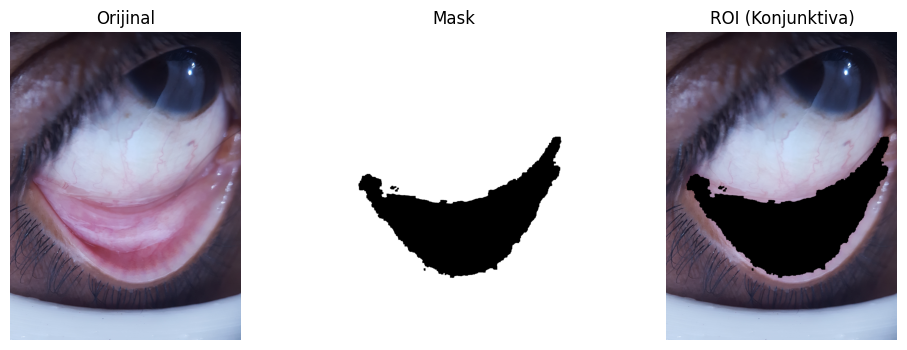

In [ ]:
img_path1 = "/content/drive/MyDrive/anemia_detection/test_dataset/conjunctiva_3.jpg"

img1, mask1, roi1 = conjunctiva_roi(img_path1)

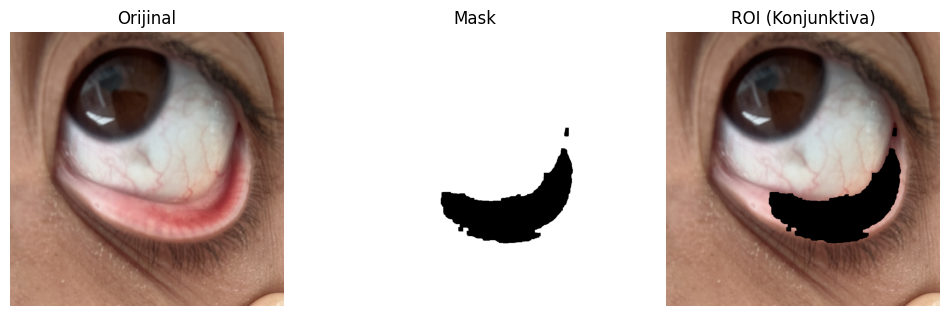

In [ ]:
img_path2 = "/content/drive/MyDrive/anemia_detection/test_dataset/conjunctiva_1.JPG"

img2, mask2, roi2 = conjunctiva_roi(img_path2)

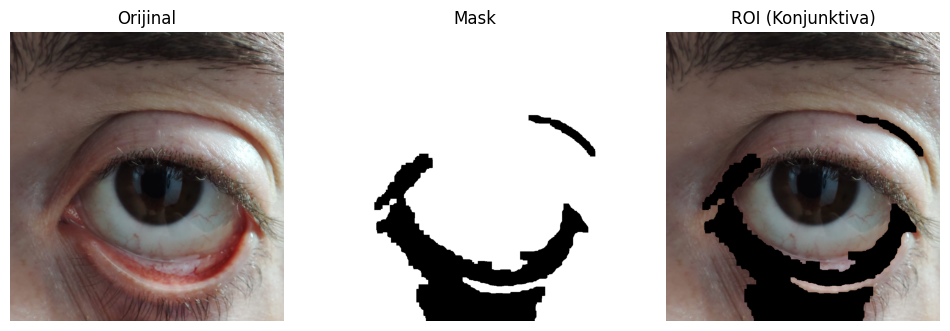

In [ ]:
img_path3 = "/content/drive/MyDrive/anemia_detection/test_dataset/conjunctiva_2.jpeg"

img3, mask3, roi3 = conjunctiva_roi(img_path3)

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def nail_roi(img_path, show=True):
    """
    Konjonktiva bölgesini LAB renk uzayında A kanalı üzerinden çıkarır.

    Returns:
        img_rgb : Orijinal RGB görüntü
        mask    : Oluşturulan binary maske
        roi     : Maskelenmiş konjonktiva bölgesi
    """

    # Görüntüyü oku
    img = cv2.imread(img_path)
    if img is None:
        raise ValueError(f"Görüntü okunamadı: {img_path}")

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # LAB renk uzayına çevir
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    _, A, _ = cv2.split(lab)

    # Triangle threshold
    _, thresh = cv2.threshold(A, 0, 255, cv2.THRESH_TRIANGLE)

    # Maskeyi ters çevir (konjonktiva genelde açık ton)
    mask = cv2.bitwise_not(thresh)

    # ROI çıkar
    roi = cv2.bitwise_and(img_rgb, img_rgb, mask=mask)

    # Görselleştirme (opsiyonel)
    if show:
        plt.figure(figsize=(12,4))

        plt.subplot(1,3,1)
        plt.title("Orijinal")
        plt.imshow(img_rgb)
        plt.axis("off")

        plt.subplot(1,3,2)
        plt.title("Mask")
        plt.imshow(mask, cmap='gray')
        plt.axis("off")

        plt.subplot(1,3,3)
        plt.title("ROI (Konjunktiva)")
        plt.imshow(roi)
        plt.axis("off")

        plt.show()

    return img_rgb, mask, roi

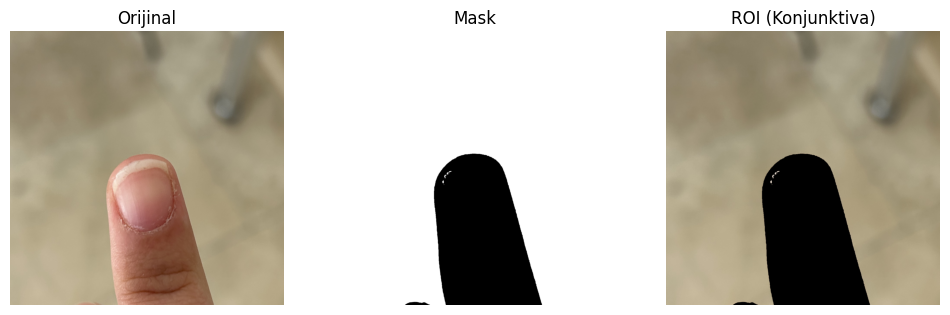

In [ ]:
img_path4  = "/content/drive/MyDrive/anemia_detection/test_dataset/nail_1.JPG"

img4, mask4, roi4 = nail_roi(img_path4)

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def palm_roi(img_path, show=True):
    """
    Konjonktiva bölgesini LAB renk uzayında A kanalı üzerinden çıkarır.

    Returns:
        img_rgb : Orijinal RGB görüntü
        mask    : Oluşturulan binary maske
        roi     : Maskelenmiş konjonktiva bölgesi
    """

    # Görüntüyü oku
    img = cv2.imread(img_path)
    if img is None:
        raise ValueError(f"Görüntü okunamadı: {img_path}")

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # LAB renk uzayına çevir
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    _, A, _ = cv2.split(lab)

    # Triangle threshold
    _, thresh = cv2.threshold(A, 0, 255, cv2.THRESH_TRIANGLE)

    # Maskeyi ters çevir (konjonktiva genelde açık ton)
    mask = cv2.bitwise_not(thresh)

    # ROI çıkar
    roi = cv2.bitwise_and(img_rgb, img_rgb, mask=mask)

    # Görselleştirme (opsiyonel)
    if show:
        plt.figure(figsize=(12,4))

        plt.subplot(1,3,1)
        plt.title("Orijinal")
        plt.imshow(img_rgb)
        plt.axis("off")

        plt.subplot(1,3,2)
        plt.title("Mask")
        plt.imshow(mask, cmap='gray')
        plt.axis("off")

        plt.subplot(1,3,3)
        plt.title("ROI (Konjunktiva)")
        plt.imshow(roi)
        plt.axis("off")

        plt.show()

    return img_rgb, mask, roi

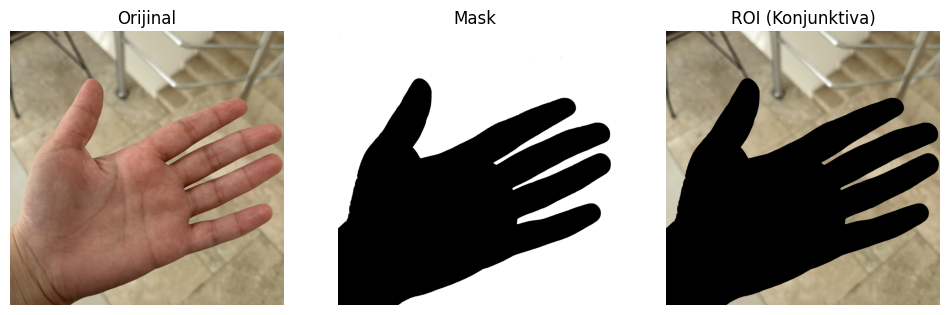

In [ ]:
img_path7  = "/content/drive/MyDrive/anemia_detection/test_dataset/palm_1.JPG"

img7, mask7, roi7 = nail_roi(img_path7)